In [3]:
import jsonlines
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jsonlines
from cattrs import unstructure, structure
from dataclasses import dataclass, field
from itertools import combinations

from scheduler.entities import RunningTask, Task, Node, Edge, NetworkTopology
from scheduler.load_info import load_nodes, load_edges, load_tasks, build_task_graph

# Generating Synthetic Data

Experimenting with creating synthetic metrics for assigned tasks. Basically, generating somewhat plausible time series for CPU, memory, etc (simulate running jobs on a cluster).

0.13831199165325153 0.01093584607400225 2533.664345390965


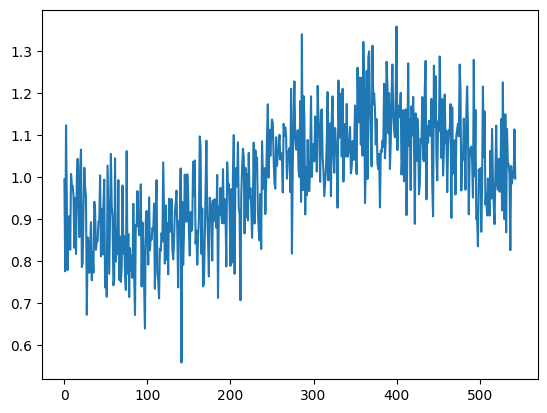

In [30]:
rng = np.random.default_rng()

size = 544

period = rng.uniform(0, 10 * size)
a = rng.uniform(0.05, 0.95)
b = 2 * np.pi / period
c = rng.uniform(0, 10 * size)

print(a, b, c)

scale_factor = 1 + a * np.sin( b * (np.arange(size) - c) )
noise = rng.normal(loc=0, scale=0.1, size=size)

cpu = scale_factor + noise

plt.plot(cpu)

# Fake Network Control Data

Experimenting with generating different aspects of army control demo data (network topo, nodes, task requests, etc).

## Exploring Current Data

Just seeing what the network topo in the CSV looks like.

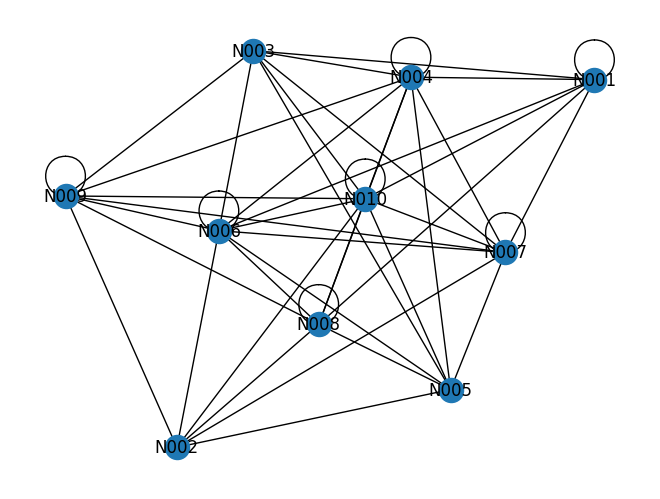

In [30]:
node_path = "dummy_data/nodes.csv"
edge_path = "dummy_data/edges.csv"
nodes = load_nodes(node_path)
edges = load_edges(edge_path)
network = NetworkTopology(nodes.values(), edges.values())
nx.draw(network._graph, with_labels=True)

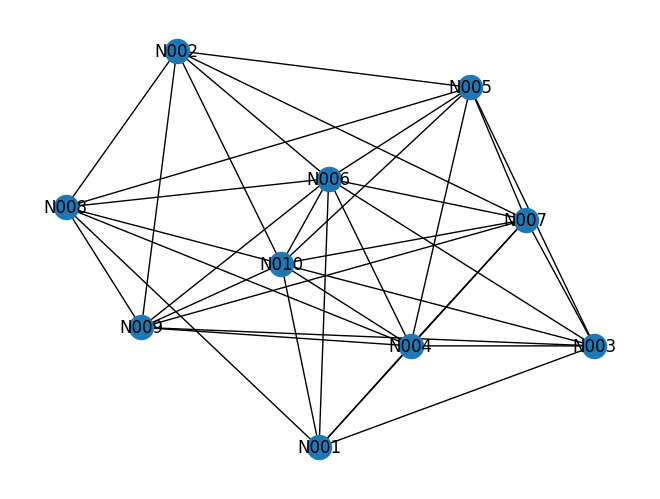

In [46]:
res = nx.Graph()
for n in network._graph.nodes:
    res.add_node(n)
for n1, n2 in combinations(res.nodes, 2):
    path = nx.shortest_path(network._graph, n1, n2)
    nx.add_path(res, path)
nx.draw(res, with_labels=True)

## Serialization

In [4]:
def serialize_jsonl(data: list, path: str):
    with jsonlines.open(path, 'w') as writer:
        if data:
            data_type = type(data[0])
            data = unstructure(data, list[data_type])
            writer.write_all(data)

def deserialize_jsonl(path: str, data_type):
    data = []
    with jsonlines.open(path, 'r') as reader:
        for record in reader:
            data.append(structure(record, data_type))
    return data

## Generate Fake Network Topo

Generate a fake compute cluster, with node and link information.

31.0


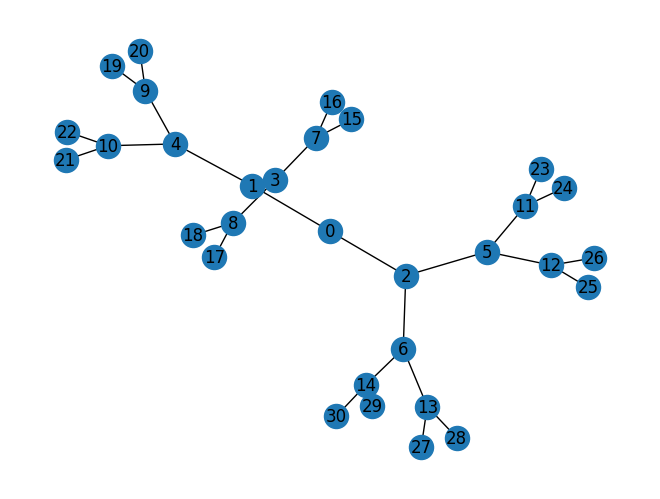

In [7]:
# Generate basic topology for network. Sparse to mimic edge network.
r = 2
h = 4
num_nodes = (r ** (h + 1) - 1) / (r - 1)
print(num_nodes)

graph = nx.balanced_tree(r, h)
nx.draw(graph, with_labels=True)

In [8]:
# Generate node specs.
import random

# Each node can be one of 4 tiers of CPU + memory.
cpu_options = [2, 4, 8, 16]
memory_options = [8, 16, 32, 64]

cpu_specs = random.choices(cpu_options, weights=reversed(cpu_options), k=len(graph.nodes))
mem_specs = [4 * cpu for cpu in cpu_specs]

gen_nodes = []
for i, (cpu, memory) in enumerate(zip(cpu_specs, mem_specs)):
    n_id = f'N{i:03}'
    node = Node(node_id=n_id, cpu_capacity=cpu, memory_capacity=memory)
    gen_nodes.append(node)
    print(node)

Node(node_id='N000', cpu_capacity=16, memory_capacity=64, network_capacity=None, used_cpu=0.0, used_memory=0.0, used_network=0.0)
Node(node_id='N001', cpu_capacity=8, memory_capacity=32, network_capacity=None, used_cpu=0.0, used_memory=0.0, used_network=0.0)
Node(node_id='N002', cpu_capacity=4, memory_capacity=16, network_capacity=None, used_cpu=0.0, used_memory=0.0, used_network=0.0)
Node(node_id='N003', cpu_capacity=2, memory_capacity=8, network_capacity=None, used_cpu=0.0, used_memory=0.0, used_network=0.0)
Node(node_id='N004', cpu_capacity=4, memory_capacity=16, network_capacity=None, used_cpu=0.0, used_memory=0.0, used_network=0.0)
Node(node_id='N005', cpu_capacity=2, memory_capacity=8, network_capacity=None, used_cpu=0.0, used_memory=0.0, used_network=0.0)
Node(node_id='N006', cpu_capacity=4, memory_capacity=16, network_capacity=None, used_cpu=0.0, used_memory=0.0, used_network=0.0)
Node(node_id='N007', cpu_capacity=4, memory_capacity=16, network_capacity=None, used_cpu=0.0, used

In [9]:
# Generate edges.
bandwidth = 100 # Set to fixed mbps for now.

gen_edges = []
for u, v in graph.edges:
    u_id = f'N{u:03}'
    v_id = f'N{v:03}'
    edge = Edge(edge_id=(u_id, v_id), capacity=bandwidth)
    gen_edges.append(edge)
    print(edge)

Edge(edge_id=('N000', 'N001'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N000', 'N002'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N001', 'N003'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N001', 'N004'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N002', 'N005'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N002', 'N006'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N003', 'N007'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N003', 'N008'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N004', 'N009'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N004', 'N010'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N005', 'N011'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N005', 'N012'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N006', 'N013'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N006', 'N014'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N007', 'N015'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N007', 'N0

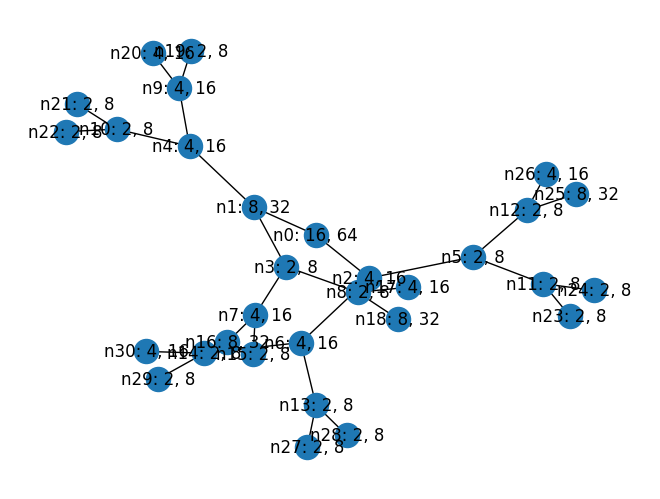

In [10]:
# View generated topo with associated CPU/memory count.
gen_graph = graph.copy(as_view=False)
nx.set_node_attributes(gen_graph, {i: node for i, node in enumerate(gen_nodes)}, 'data')
labels = {i: f'n{i}: {node.cpu_capacity}, {node.memory_capacity}' for i, node in enumerate(gen_nodes)}
nx.draw(gen_graph, with_labels=True, labels=labels)

## Generating Task Information

Tasks can either be independent, or have communication dependencies between each other, so we must generate various task "graphs".

Num Tasks: 248


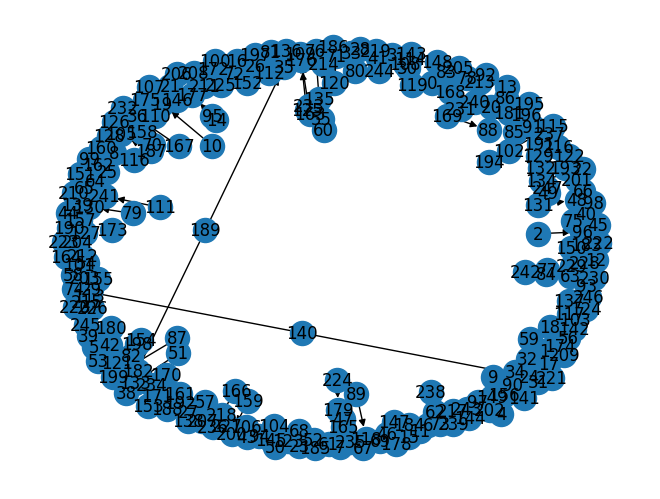

In [16]:
# Generate task graphs.
num_tasks = int(num_nodes * 8)
print(f'Num Tasks: {num_tasks}')
# Number of edges should scale linearly with nodes -> maintains sparsity.
frac = (num_tasks / num_tasks ** 2) / 4
task_graph = nx.fast_gnp_random_graph(num_tasks, p=frac, directed=True)
nx.draw(task_graph, with_labels=True)

In [17]:
# Visualize different task graphs.
comps = list(nx.weakly_connected_components(task_graph))
num_comps = 0
for comp in comps:
    num_comps += 1
    print(comp)
num_comps

{0}
{1}
{96, 2}
{3}
{4}
{5}
{6}
{224, 179, 7}
{8}
{9}
{10, 19}
{11}
{12}
{13}
{177, 14, 95}
{15}
{16}
{17}
{18}
{20}
{21}
{134, 22}
{23}
{24, 74, 140}
{25}
{26}
{27}
{28}
{29}
{114, 108, 30, 143}
{31}
{32}
{33}
{34}
{35, 189, 38}
{36}
{37}
{39}
{40}
{41}
{42}
{43}
{44}
{45}
{46}
{165, 47}
{48, 131}
{49, 247}
{50}
{51, 133}
{52}
{53}
{54}
{135, 60, 76, 55}
{56}
{57}
{58}
{59}
{61}
{62}
{230, 77, 242, 84, 63}
{64}
{65}
{66}
{67}
{68}
{69}
{126, 70}
{120, 71}
{72}
{73}
{75}
{78}
{130, 79}
{80}
{81}
{82}
{88, 169, 83}
{85}
{86}
{199, 87}
{89, 118}
{90}
{91}
{92, 213}
{93}
{94}
{97}
{98}
{99}
{100}
{101}
{194, 115, 102}
{103}
{104}
{105, 187}
{106}
{107}
{163, 233, 109, 176, 125}
{110}
{241, 111}
{112}
{113}
{116}
{117}
{119}
{121}
{122}
{123}
{124}
{127}
{128}
{129}
{132}
{136}
{137}
{138}
{139}
{141}
{142}
{144}
{145}
{146}
{147}
{148}
{149}
{150}
{151}
{152}
{153}
{154, 198}
{155}
{156}
{157}
{158}
{200, 159}
{160}
{161, 188}
{162}
{212, 164}
{236, 166}
{232, 167}
{168}
{170}
{171}
{172}

199

In [20]:
import time


def make_peer_bws(graph: nx.DiGraph, node: int):
    peer_bws = {}
    rng = np.random.default_rng()
    for n in graph.neighbors(node):
        peer_id = f'T{n:03}'
        peer_bws[peer_id] = np.clip(rng.exponential(3) + 1, 1, 100)
    return peer_bws


def process_comp(task_graph: nx.DiGraph, comp: list[int], arrival_time: int = 0) -> list[Task]:
    rng = np.random.default_rng()
    tasks = []
    for v in comp:
        task_id = f'T{v:03}'
        
        cpu = np.clip(rng.rayleigh(4), 0, 16)
        memory = np.clip(rng.rayleigh(16), 0, 64)
        offset = max(0, arrival_time)
        peer_bws = make_peer_bws(task_graph, v)
        duration = rng.uniform(3 * 60, 15 * 60)
                                 
        task = Task(
            task_id=task_id,
            arrival_offset_s=offset,
            initial_cpu=cpu,
            initial_memory=memory,
            peer_bandwidths=peer_bws,
            duration_s=duration
        )
        tasks.append(task)
    return tasks

In [30]:
# Generate task specs for task graph.
interval = 30
rng = np.random.default_rng()

tasks = []
comp_idx = []
curr_time = 0
# Limit the number of tasks that arrive at the same time.
max_tasks_per_epoch = 60
num_tasks = 0
for i, comp in enumerate(comps):
    out = process_comp(task_graph, comp, arrival_time=curr_time)
    tasks += out
    num_tasks += len(comp)
    comp_idx += [i] * len(out)
    
    if num_tasks > max_tasks_per_epoch:
        curr_time += interval
        num_tasks = 0
    
    print(f'COMP {i}:\n')
    for task in out:
        print(task)
    print()

COMP 0:

Task(task_id='T000', arrival_offset_s=0, duration_s=699.2256141818661, initial_cpu=np.float64(4.417697154750547), initial_memory=np.float64(30.60894526627025), peer_bandwidths={})

COMP 1:

Task(task_id='T001', arrival_offset_s=0, duration_s=727.7591498931639, initial_cpu=np.float64(2.5175722544436487), initial_memory=np.float64(19.975643912195693), peer_bandwidths={})

COMP 2:

Task(task_id='T096', arrival_offset_s=0, duration_s=429.9132660211136, initial_cpu=np.float64(4.855474565204034), initial_memory=np.float64(8.502489609075647), peer_bandwidths={})
Task(task_id='T002', arrival_offset_s=0, duration_s=625.7861435640066, initial_cpu=np.float64(6.9635883240044585), initial_memory=np.float64(38.56757087142761), peer_bandwidths={'T096': np.float64(4.532398779895544)})

COMP 3:

Task(task_id='T003', arrival_offset_s=0, duration_s=450.5141547387471, initial_cpu=np.float64(4.640316728712347), initial_memory=np.float64(22.250754395759262), peer_bandwidths={})

COMP 4:

Task(task_

In [22]:
# Visualize arrival times for different tasks in the format: task id, task graph (component) idx, arrival time offset (s)
for comp_i, t in sorted(zip(comp_idx, tasks), key=lambda x: x[1].arrival_offset_s):
    print(t.task_id, comp_i, t.arrival_offset_s)

T000 0 30
T001 1 60
T096 2 90
T002 2 90
T003 3 120
T004 4 150
T005 5 180
T006 6 210
T224 7 240
T179 7 240
T007 7 240
T008 8 270
T009 9 300
T010 10 330
T019 10 330
T011 11 360
T012 12 390
T013 13 420
T177 14 450
T014 14 450
T095 14 450
T015 15 480
T016 16 510
T017 17 540
T018 18 570
T020 19 600
T021 20 630
T134 21 660
T022 21 660
T023 22 690
T024 23 720
T074 23 720
T140 23 720
T025 24 750
T026 25 780
T027 26 810
T028 27 840
T029 28 870
T114 29 900
T108 29 900
T030 29 900
T143 29 900
T031 30 930
T032 31 960
T033 32 990
T034 33 1020
T035 34 1050
T189 34 1050
T038 34 1050
T036 35 1080
T037 36 1110
T039 37 1140
T040 38 1170
T041 39 1200
T042 40 1230
T043 41 1260
T044 42 1290
T045 43 1320
T046 44 1350
T165 45 1380
T047 45 1380
T048 46 1410
T131 46 1410
T049 47 1440
T247 47 1440
T050 48 1470
T051 49 1500
T133 49 1500
T052 50 1530
T053 51 1560
T054 52 1590
T135 53 1620
T060 53 1620
T076 53 1620
T055 53 1620
T056 54 1650
T057 55 1680
T058 56 1710
T059 57 1740
T061 58 1770
T062 59 1800
T230 60 1

## Serialize Data

Save as JSONL so we can have nested data structures.

In [31]:
task_gen_path = 'tasks.jsonl'
sorted_data = sorted(tasks, key=lambda x: x.arrival_offset_s)
serialize_jsonl(sorted_data, task_gen_path)

In [27]:
node_gen_path = 'nodes.jsonl'
serialize_jsonl(gen_nodes, node_gen_path)

In [28]:
edge_gen_path = 'edges.jsonl'
serialize_jsonl(gen_edges, edge_gen_path)